# 목표

---

- [ ]  AG_News dataset 준비
    - Huggingface dataset의 `fancyzhx/ag_news`를 load합니다. (기존과 같이 train과 test 모두 5% 데이터만 사용)
    - `collate_fn` 함수에 다음 수정사항들을 반영하면 됩니다.
        - Truncation과 관련된 부분들을 지웁니다.
- [ ]  Classifier output, loss function, accuracy function 변경
    - 뉴스 기사 분류 문제는 binary classification이 아닌 일반적인 classification 문제입니다. **MNIST 과제(링크)**에서 했던 것 처럼 `nn.CrossEntropyLoss` 를 추가하고 `TextClassifier`의 출력 차원을 잘 조정하여 task를 풀 수 있도록 수정해주세요.
    - 정확도를 재는 `accuracy` 함수는 classification에 맞춰 수정해주세요.
- [ ]  학습 결과 report
    - DistilBERT 실습과 같은 방식으로
        
        **1) epoch 마다의 train loss를 출력**하고
        
        **2) 최종 모델의 test accuracy**를 report 합니다.
        

## 제출자료

---

- 위의 사항들을 구현하고, epoch마다의 train loss와 최종 모델의 test accuracy가 print된 notebook을 public github repository에 업로드하여 공유해주시면 됩니다.
- **반드시 출력 결과가 남아있어야 합니다.**



In [1]:
!pip install tqdm boto3 requests regex sentencepiece sacremoses datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.5/13.5 MB 106.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.4/84.4 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.9 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This beh

# 1. Data set preparing
---

## 데이터 확인 및 Tokenizer 선정




* distilbert-base-uncased에 가장 적합한 tokenizer는 DistilBERTTokenizer입니다.

  - DistilBERTTokenizer는 distilbert-base-uncased 모델을 위해 특별히 설계된 tokenizer로, 다음과 같은 기능을 제공합니다.

  - WordPiece 토큰화: 단어를 subword 단위로 분리하여 어휘 크기를 줄이고 희귀 단어를 처리하는 데 효과적입니다
  - 케이스 무시: distilbert-base-uncased 모델은 케이스를 구분하지 않으므로, tokenizer도 케이스를 무시하도록 설계되었습니다.
- 특수 토큰: [CLS], [SEP]와 같은 특수 토큰을 추가하여 문장 구조를 나타냅니다.
패딩 및 잘림: 입력 시퀀스의 길이를 일정하게 유지하기 위해 패딩과 잘림을 수행합니다.

In [12]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import DistilBertTokenizerFast, DistilBertModel
from torch.optim import Adam
import matplotlib.pyplot as plt
import numpy as np


# GPU 사용 여부
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DistilBERT 모델용 tokenizer 로드 (pretrained)
# 이 tokenizer는 문장을 토큰화해서 모델이 이해할 수 있는 input_ids로 변환해줌
tokenizer = torch.hub.load('huggingface/pytorch-transformers', 'tokenizer', 'distilbert-base-uncased')

# AG News 데이터셋 로드 (5%만 사용)
train_ds = load_dataset("fancyzhx/ag_news", split="train[:5%]")
test_ds = load_dataset("fancyzhx/ag_news", split="test[:5%]")


Using cache found in /root/.cache/torch/hub/huggingface_pytorch-transformers_main


In [13]:
import pandas as pd


display(
    pd.DataFrame(train_ds)
)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
...,...,...
5995,Nobody is neutral about the great Google gambl...,2
5996,Gloves are off as Abbey war turns dirty ANYONE...,2
5997,Online hits climb the charts as radio embraces...,3
5998,Epson develops worlds lightest flying robot Th...,3


In [14]:
"""데이터 레이블 구성 확인"""

labels = pd.DataFrame(train_ds)['label']
cases = labels.unique()
print(cases)

[2 3 1 0]


> 데이터 레이블 : [ 0, 1, 2, 3 ]



__


## 데이터 전처리
---

In [15]:

# 데이터를 배치로 묶기 위한 함수 정의
def collate_fn(batch):
    texts, labels = zip(*[(row['text'], row['label']) for row in batch])
    tokens = tokenizer(list(texts), padding=True, return_tensors="pt")
    labels = torch.tensor(labels)
    return tokens['input_ids'], tokens['attention_mask'], labels

# DataLoader 생성
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, collate_fn=collate_fn)


truncation = False로 설정하는 것과 truncation 관련 부분을 아예 지우는 것의 차이는 다음과 같습니다.

- truncation = False: tokenizer 함수를 호출할 때 truncation=False로 설정하면, 입력 텍스트가 max_length보다 길더라도 텍스트를 자르지 않고 전체 텍스트를 토큰화합니다. 이 경우, 토큰화된 결과의 길이가 max_length를 초과할 수 있습니다.
- truncation 관련 부분 제거: tokenizer 함수를 호출할 때 truncation과 max_length 관련 인자를 모두 제거하면, tokenizer는 기본 설정에 따라 동작합니다. Hugging Face Transformers의 tokenizer는 기본적으로 truncation=True와 model_max_length 값을 사용합니다. 즉, 입력 텍스트가 모델의 최대 입력 길이(model_max_length)보다 길면 텍스트를 자르고, 그렇지 않으면 전체 텍스트를 토큰화합니다.

- <u>**이번 과제에서는 truncation 관련 부분을 아예 지우는 것이 더 적합합니다.**</u>


과제 요구사항: 과제에서는 truncation과 관련된 부분을 지우라고 명시되어 있습니다.

이는 텍스트를 자르지 않고 전체 텍스트를 사용하여 모델을 학습시키라는 의미입니다.

- 모델의 최대 입력 길이: DistilBERT의 최대 입력 길이(model_max_length)는 512입니다. AG News 데이터셋의 텍스트는 대부분 512 토큰보다 짧기 때문에, truncation=False로 설정하더라도 텍스트가 잘리는 경우는 거의 없을 것입니다.
- 하지만, 일부 텍스트가 512 토큰보다 길 경우, truncation=False로 설정하면 토큰화된 결과의 길이가 512를 초과하여 모델에 입력될 수 있습니다. 이는 모델 학습에 오류를 발생시킬 수 있습니다.
- 따라서, 과제 요구사항을 충족하고 모델 학습의 안정성을 확보하기 위해 truncation 관련 부분을 아예 지우는 것이 더 적합합니다.

이렇게 하면 tokenizer는 기본 설정에 따라 동작하며, 모델의 최대 입력 길이를 초과하는 텍스트는 자동으로 잘립니다.

** 요약. truncation=False로 설정하는 것과 truncation 관련 부분을 아예 지우는 것은 토큰화 결과의 길이에 차이가 있습니다. 이번 과제에서는 truncation 관련 부분을 아예 지우는 것이 과제 요구사항을 충족**하고 모델 학습의 안정성을 확보하는 데 더 적합합니다.

이제 pre-trained DistilBERT를 불러옵니다. 이번에는 PyTorch hub에서 제공하는 DistilBERT를 불러옵니다
* **ps. 사실은 huggingface에서 불러오는것**

In [16]:
"""DistilBERT 모델을 PyTorch Hub에서 로드 후 model 구조 출력"""


model = torch.hub.load('huggingface/pytorch-transformers', 'model', 'distilbert-base-uncased')
model

Using cache found in /root/.cache/torch/hub/huggingface_pytorch-transformers_main


DistilBertModel(
  (embeddings): Embeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (layer): ModuleList(
      (0-5): 6 x TransformerBlock(
        (attention): DistilBertSdpaAttention(
          (dropout): Dropout(p=0.1, inplace=False)
          (q_lin): Linear(in_features=768, out_features=768, bias=True)
          (k_lin): Linear(in_features=768, out_features=768, bias=True)
          (v_lin): Linear(in_features=768, out_features=768, bias=True)
          (out_lin): Linear(in_features=768, out_features=768, bias=True)
        )
        (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (ffn): FFN(
          (dropout): Dropout(p=0.1, inplace=False)
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): L

출력 결과를 통해 우리는 DistilBERT의 architecture는 일반적인 Transformer와 동일한 것을 알 수 있습니다.
Embedding layer로 시작해서 여러 layer의 Attention, FFN를 거칩니다.

이제 DistilBERT를 거치고 난 `[CLS]` token의 representation을 가지고 text 분류를 하는 모델을 구현합시다.

+ `TextClassifier`의 `encoder`를 불러온 DistilBERT
+ `classifier`를 linear layer로 설정
+ `forward` 함수에서 순차적으로 사용하여 예측 결과를 반환


In [17]:
from torch import nn

# 텍스트 분류 모델 정의 (DistilBERT + Linear layer)
class TextClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = DistilBertModel.from_pretrained("distilbert-base-uncased")

        for param in self.encoder.parameters():
            param.requires_grad = False  # encoder freeze

        self.classifier = nn.Linear(768, 4)  # 4-class 분류기

    def forward(self, input_ids, attention_mask):
        output = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_token = output.last_hidden_state[:, 0]

        return self.classifier(cls_token)

model = TextClassifier()

* 마지막 classifier layer를 제외한 나머지 부분을 freeze

위의 코드는 `encoder`에 해당하는 parameter들의 `requires_grad`를 `False`로 설정하는 모습입니다.
`requires_grad`를 `False`로 두는 경우, gradient 계산 및 업데이트가 이루어지지 않아 결과적으로 학습이 되지 않습니다.
즉, 마지막 `classifier`에 해당하는 linear layer만 학습이 이루어집니다.
이런 식으로 특정 부분들을 freeze하게 되면 효율적으로 학습을 할 수 있습니다.

마지막으로 이전과 같은 코드를 사용하여 학습 결과를 확인해봅시다.

In [18]:
def accuracy(model, dataloader):
    model.eval()
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in dataloader:
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            preds = model(input_ids, attention_mask)
            preds = torch.argmax(preds, dim=-1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)
    return total_correct / total_samples



In [19]:
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt

# 학습 설정
lr = 0.001
model = model.to('cuda')  # 모델을 GPU로 이동

""" 이진분류가 아니기때문에 변경 """
# loss_fn = nn.BCEWithLogitsLoss()  # 이진 분류용 손실 함수
loss_fn = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr=lr)
n_epochs = 20

# 학습을 위한 기록 리스트
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

# 학습 루프
for epoch in range(n_epochs):
    model.train()
    total_train_loss = 0

    for input_ids, attention_mask, labels in train_loader:
        input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)

        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss = loss_fn(preds, labels)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # 정확도 및 테스트 손실 계산
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for input_ids, attention_mask, labels in test_loader:
            input_ids, attention_mask, labels = input_ids.to(device), attention_mask.to(device), labels.to(device)
            preds = model(input_ids, attention_mask)
            loss = loss_fn(preds, labels)
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    train_acc = accuracy(model, train_loader)
    test_acc = accuracy(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")



Epoch  1 | Train Loss: 0.7907 | Train Acc: 0.848 | Test Acc: 0.855
Epoch  2 | Train Loss: 0.4915 | Train Acc: 0.855 | Test Acc: 0.861
Epoch  3 | Train Loss: 0.4367 | Train Acc: 0.861 | Test Acc: 0.868
Epoch  4 | Train Loss: 0.4136 | Train Acc: 0.864 | Test Acc: 0.871
Epoch  5 | Train Loss: 0.3946 | Train Acc: 0.865 | Test Acc: 0.879
Epoch  6 | Train Loss: 0.3847 | Train Acc: 0.865 | Test Acc: 0.868
Epoch  7 | Train Loss: 0.3704 | Train Acc: 0.862 | Test Acc: 0.876
Epoch  8 | Train Loss: 0.3696 | Train Acc: 0.867 | Test Acc: 0.866
Epoch  9 | Train Loss: 0.3575 | Train Acc: 0.873 | Test Acc: 0.874
Epoch 10 | Train Loss: 0.3530 | Train Acc: 0.873 | Test Acc: 0.874
Epoch 11 | Train Loss: 0.3446 | Train Acc: 0.879 | Test Acc: 0.884
Epoch 12 | Train Loss: 0.3405 | Train Acc: 0.879 | Test Acc: 0.884
Epoch 13 | Train Loss: 0.3399 | Train Acc: 0.884 | Test Acc: 0.879
Epoch 14 | Train Loss: 0.3366 | Train Acc: 0.883 | Test Acc: 0.889
Epoch 15 | Train Loss: 0.3324 | Train Acc: 0.885 | Test Acc: 0


- [x] 학습 결과 report
    - DistilBERT 실습과 같은 방식으로
        
        **1) epoch 마다의 train loss를 출력**
        
        **2) 최종 모델의 test accuracy**를 report
        


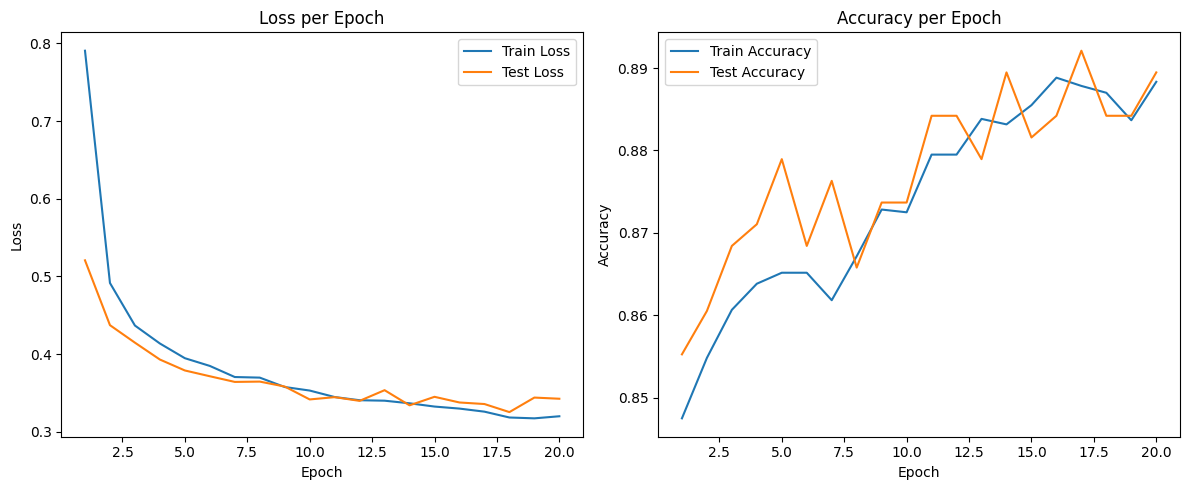

In [22]:
import matplotlib.pyplot as plt
import os

# 디렉토리 생성
os.makedirs("./img", exist_ok=True)


# Loss 그래프
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs+1), train_losses, label='Train Loss')
plt.plot(range(1, n_epochs+1), test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss per Epoch')
plt.savefig("./img/loss_curve_ag.png")

plt.legend()


# Accuracy 그래프

plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs+1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, n_epochs+1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy per Epoch')
plt.savefig("./img/accuracy_plot_ag.png")
plt.legend()

plt.tight_layout()
plt.show()
